# Multimodal Random Forest: Linguistic + Acoustic Features

Combines 24 CYMO linguistic features with acoustic features (F0, energy, ZCR, etc.)  
and compares: linguistic only vs acoustic only vs combined.

---

In [2]:
# ╔══════════════════════════════════════════════════════════╗
# ║  PATHS                                                  ║
# ╚══════════════════════════════════════════════════════════╝

# ParkCeleb
PARKCELEB_DIR = '../ParkCeleb'
CYMO_PC       = '../ParkCeleb/ann.cymo_parkceleb_per_recording.csv'
META_PC       = './cymo_parkceleb_per_recording_metadata.csv'
FEAT_CSV      = './mrmr_top10_features.csv'  # your 24 selected CYMO features

# KCL
KCL_DIR       = '../KCL'
CYMO_KCL_RT   = '../KCL/ann.cymo_kcl_readtext_full.csv'
META_KCL_RT   = './cymo_kcl_readtext_full_metadata.csv'
CYMO_KCL_SD   = '../KCL/ann.cymo_kcl_dialogue_full.csv'
META_KCL_SD   = './cymo_kcl_dialogue_full_metadata.csv'

# Pre-computed acoustic features (set to None to extract fresh)
PC_ACOUSTIC_CSV = './parkceleb_acoustic_features.csv'   # e.g. './parkceleb_acoustic.csv' if already extracted
KCL_ACOUSTIC_CSV = './kcl_acoustic.csv'  # e.g. './kcl_audio_features.csv' from notebook 01

In [3]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import librosa, parselmouth, joblib, os, glob, time, warnings
from scipy import ndimage
warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, recall_score,
                             roc_auc_score, confusion_matrix, roc_curve, auc)
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10, 'axes.titleweight': 'bold'})

---
## 1 — Extract acoustic features

In [4]:
# ============================================================
# 1.1  Acoustic feature extraction function
# ============================================================

def extract_acoustic(filepath, target_sr=16000):
    """Extract acoustic features from one audio file. Returns dict or None."""
    try:
        y, sr = librosa.load(filepath, sr=target_sr)
        duration = len(y) / sr
        if duration < 1.0:
            return None

        fl = int(sr * 0.025)
        hl = int(sr * 0.010)

        # RMS energy
        rms = librosa.feature.rms(y=y, frame_length=fl, hop_length=hl)[0]
        rms_db = 20 * np.log10(rms + 1e-10)

        # ZCR
        zcr = librosa.feature.zero_crossing_rate(y, frame_length=fl, hop_length=hl)[0]

        # Spectral centroid
        cent = librosa.feature.spectral_centroid(y=y, sr=sr, hop_length=hl)[0]

        # F0 via Praat
        snd = parselmouth.Sound(y.astype(np.float64), sampling_frequency=sr)
        pitch = snd.to_pitch(time_step=0.01, pitch_floor=75.0, pitch_ceiling=500.0)
        f0 = pitch.selected_array['frequency']
        f0_voiced = f0[f0 > 0]

        # Intensity via Praat
        intensity = snd.to_intensity(time_step=0.01, minimum_pitch=75.0)
        int_vals = intensity.values[0]

        # VAD-based speech fraction
        sorted_rms = np.sort(rms_db)
        noise_floor = np.median(sorted_rms[:max(1, len(sorted_rms)//10)])
        vad = (rms_db >= noise_floor + 15).astype(float)
        vad = ndimage.median_filter(vad, size=5)
        speech_frac = vad.mean()

        feats = {
            'duration_s': duration,
            'rms_mean': rms.mean(),
            'rms_std': rms.std(),
            'rms_db_mean': rms_db.mean(),
            'rms_db_std': rms_db.std(),
            'zcr_mean': zcr.mean(),
            'zcr_std': zcr.std(),
            'centroid_mean': cent.mean(),
            'centroid_std': cent.std(),
            'f0_mean': f0_voiced.mean() if len(f0_voiced) > 0 else np.nan,
            'f0_std': f0_voiced.std() if len(f0_voiced) > 0 else np.nan,
            'f0_range': (f0_voiced.max() - f0_voiced.min()) if len(f0_voiced) > 1 else np.nan,
            'voicing_frac': len(f0_voiced) / len(f0) if len(f0) > 0 else np.nan,
            'intensity_mean': int_vals.mean(),
            'intensity_std': int_vals.std(),
            'speech_frac': speech_frac,
        }
        return feats
    except Exception as e:
        return None

In [5]:
# ============================================================
# 1.2  Extract ParkCeleb acoustic features (or load from CSV)
# ============================================================
if PC_ACOUSTIC_CSV and os.path.isfile(PC_ACOUSTIC_CSV):
    pc_acoustic = pd.read_csv(PC_ACOUSTIC_CSV)
    print(f'Loaded ParkCeleb acoustic features: {len(pc_acoustic)} rows')
else:
    print('Extracting ParkCeleb acoustic features...')
    print('(This runs once and saves to CSV. ~2-5 min per 100 files)\n')
    
    rows = []
    count = 0
    for group in ['CN', 'PD']:
        group_dir = os.path.join(PARKCELEB_DIR, group)
        if not os.path.isdir(group_dir): continue
        for subj in sorted(os.listdir(group_dir)):
            subj_dir = os.path.join(group_dir, subj)
            if not os.path.isdir(subj_dir): continue
            for vid_id in sorted(os.listdir(subj_dir)):
                vid_dir = os.path.join(subj_dir, vid_id)
                if not os.path.isdir(vid_dir): continue
                # Find audio file
                audio_files = [f for f in os.listdir(vid_dir)
                               if f.endswith(('.wav','.mp3','.flac','.m4a'))]
                if not audio_files: continue
                
                fpath = os.path.join(vid_dir, audio_files[0])
                feats = extract_acoustic(fpath)
                if feats:
                    feats['group'] = group
                    feats['subject'] = subj
                    feats['video_id'] = vid_id
                    rows.append(feats)
                
                count += 1
                if count % 100 == 0:
                    print(f'  {count} files processed...')
    
    pc_acoustic = pd.DataFrame(rows)
    pc_acoustic.to_csv('parkceleb_acoustic.csv', index=False)
    print(f'\nDone: {len(pc_acoustic)} files. Saved to parkceleb_acoustic.csv')
    PC_ACOUSTIC_CSV = 'parkceleb_acoustic.csv'

Loaded ParkCeleb acoustic features: 298 rows


In [6]:
# ============================================================
# 1.3  Extract KCL acoustic features (or load from CSV)
# ============================================================
if KCL_ACOUSTIC_CSV and os.path.isfile(KCL_ACOUSTIC_CSV):
    kcl_acoustic = pd.read_csv(KCL_ACOUSTIC_CSV)
    print(f'Loaded KCL acoustic features: {len(kcl_acoustic)} rows')
else:
    print('Extracting KCL acoustic features...')
    rows = []
    for task in ['ReadText', 'SpontaneousDialogue']:
        for group_folder in ['HC', 'PD']:
            folder = os.path.join(KCL_DIR, task, group_folder)
            if not os.path.isdir(folder): continue
            group_label = 'CN' if group_folder == 'HC' else 'PD'
            for f in sorted(os.listdir(folder)):
                if not f.endswith('.wav'): continue
                fpath = os.path.join(folder, f)
                feats = extract_acoustic(fpath)
                if feats:
                    name = os.path.splitext(f)[0]
                    parts = name.split('_')
                    feats['group'] = group_label
                    feats['subject'] = parts[0] if parts else name
                    feats['task'] = task
                    feats['filename'] = f
                    rows.append(feats)
    
    kcl_acoustic = pd.DataFrame(rows)
    kcl_acoustic.to_csv('kcl_acoustic.csv', index=False)
    print(f'Done: {len(kcl_acoustic)} files. Saved to kcl_acoustic.csv')
    KCL_ACOUSTIC_CSV = 'kcl_acoustic.csv'

Loaded KCL acoustic features: 73 rows


---
## 2 — Build combined feature sets

In [7]:
# ============================================================
# 2.1  Aggregate acoustic features to subject level
# ============================================================
acoustic_cols = [
                 'f0_std', 'f0_range', 'speech_frac']

# ParkCeleb: aggregate per subject
pc_ac_subj = pc_acoustic.groupby('subject').agg(
    {**{c: 'mean' for c in acoustic_cols}, 'group': 'first'}
).reset_index()
pc_ac_subj['label'] = (pc_ac_subj['group'] == 'PD').astype(int)
# Prefix acoustic columns to avoid name clashes with CYMO
pc_ac_subj = pc_ac_subj.rename(columns={c: f'ac_{c}' for c in acoustic_cols})
ac_feat_cols = [f'ac_{c}' for c in acoustic_cols]

print(f'ParkCeleb acoustic (subject level): {len(pc_ac_subj)} subjects, {len(ac_feat_cols)} features')

# KCL: aggregate per subject (across tasks)
kcl_ac_subj = kcl_acoustic.groupby('subject').agg(
    {**{c: 'mean' for c in acoustic_cols}, 'group': 'first'}
).reset_index()
kcl_ac_subj['label'] = (kcl_ac_subj['group'] == 'PD').astype(int)
kcl_ac_subj = kcl_ac_subj.rename(columns={c: f'ac_{c}' for c in acoustic_cols})

print(f'KCL acoustic (subject level): {len(kcl_ac_subj)} subjects')

ParkCeleb acoustic (subject level): 100 subjects, 3 features
KCL acoustic (subject level): 38 subjects


In [8]:
# ============================================================
# 2.2  Load CYMO linguistic features, aggregate to subject level
# ============================================================
cymo = pd.read_csv(CYMO_PC)
meta = pd.read_csv(META_PC)
ling_features = pd.read_csv(FEAT_CSV)['feature'].tolist()

tid_col = 'TID' if 'TID' in cymo.columns else cymo.columns[0]
meta_tid = 'TID' if 'TID' in meta.columns else meta.columns[0]

pc_ling = cymo.merge(meta[[meta_tid, 'group', 'subject']].drop_duplicates(),
                     left_on=tid_col, right_on=meta_tid, how='inner')
pc_ling['label'] = (pc_ling['group'] == 'PD').astype(int)
for col in ling_features:
    pc_ling[col] = pd.to_numeric(pc_ling.get(col, 0), errors='coerce')

# Aggregate to subject level (mean only for cross-corpus compatibility)
pc_ling_subj = pc_ling.groupby('subject').agg(
    {**{f: 'mean' for f in ling_features}, 'label': 'first'}
).reset_index()

print(f'ParkCeleb linguistic (subject level): {len(pc_ling_subj)} subjects, {len(ling_features)} features')

# Same for KCL
kcl_ling_dfs = []
for cymo_path, meta_path in [(CYMO_KCL_RT, META_KCL_RT), (CYMO_KCL_SD, META_KCL_SD)]:
    try:
        c = pd.read_csv(cymo_path)
        m = pd.read_csv(meta_path)
        tc = 'TID' if 'TID' in c.columns else c.columns[0]
        mc = 'TID' if 'TID' in m.columns else m.columns[0]
        sc = next((x for x in m.columns if x in ('subject', 'subject_id')), None)
        merged = c.merge(m[[mc, 'group', sc]].drop_duplicates(), left_on=tc, right_on=mc, how='inner')
        if sc != 'subject': merged = merged.rename(columns={sc: 'subject'})
        merged['label'] = (merged['group'] == 'PD').astype(int)
        kcl_ling_dfs.append(merged)
    except FileNotFoundError:
        pass

if kcl_ling_dfs:
    kcl_ling = pd.concat(kcl_ling_dfs, ignore_index=True)
    for col in ling_features:
        kcl_ling[col] = pd.to_numeric(kcl_ling.get(col, 0), errors='coerce')
    kcl_ling_subj = kcl_ling.groupby('subject').agg(
        {**{f: 'mean' for f in ling_features}, 'label': 'first'}
    ).reset_index()
    print(f'KCL linguistic (subject level): {len(kcl_ling_subj)} subjects')
else:
    kcl_ling_subj = None
    print('KCL linguistic: not available')

ParkCeleb linguistic (subject level): 100 subjects, 24 features
KCL linguistic (subject level): 38 subjects


In [9]:
# ============================================================
# 2.3  Merge linguistic + acoustic for each dataset
# ============================================================

# ParkCeleb combined
pc_combined = pc_ling_subj.merge(pc_ac_subj[['subject'] + ac_feat_cols],
                                 on='subject', how='inner')
pc_combined[ling_features + ac_feat_cols] = pc_combined[ling_features + ac_feat_cols].fillna(
    pc_combined[ling_features + ac_feat_cols].median())

combined_feats = ling_features + ac_feat_cols

print(f'ParkCeleb combined: {len(pc_combined)} subjects, {len(combined_feats)} features')
print(f'  Linguistic: {len(ling_features)}  |  Acoustic: {len(ac_feat_cols)}  |  Total: {len(combined_feats)}')

# KCL combined
if kcl_ling_subj is not None:
    kcl_combined = kcl_ling_subj.merge(kcl_ac_subj[['subject'] + ac_feat_cols],
                                       on='subject', how='inner')
    kcl_combined[ling_features + ac_feat_cols] = kcl_combined[ling_features + ac_feat_cols].fillna(0)
    print(f'KCL combined: {len(kcl_combined)} subjects')
else:
    kcl_combined = None

ParkCeleb combined: 100 subjects, 27 features
  Linguistic: 24  |  Acoustic: 3  |  Total: 27
KCL combined: 38 subjects


---
## 3 — Compare: Linguistic vs Acoustic vs Combined

In [10]:
# ============================================================
# 3.1  Evaluation function
# ============================================================
N_SPLITS = 10

def run_experiment(pc_data, kcl_data, feat_list, label):
    """Train on ParkCeleb, test on both PC test split and KCL."""
    results = []
    for seed in range(N_SPLITS):
        cn = pc_data[pc_data['label']==0].sample(frac=1, random_state=seed)
        pd_g = pc_data[pc_data['label']==1].sample(frac=1, random_state=seed)
        cs, ps = int(len(cn)*0.7), int(len(pd_g)*0.7)
        train = pd.concat([cn.iloc[:cs], pd_g.iloc[:ps]])
        test = pd.concat([cn.iloc[cs:], pd_g.iloc[ps:]])

        sc = StandardScaler()
        X_tr = sc.fit_transform(train[feat_list].values)
        X_te = sc.transform(test[feat_list].values)

        rf = RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=3,
                                    max_features='sqrt', class_weight='balanced',
                                    random_state=42, n_jobs=-1)
        rf.fit(X_tr, train['label'].values)
        y_te = test['label'].values
        y_prob = rf.predict_proba(X_te)[:, 1]

        r = {
            'label': label, 'seed': seed,
            'pc_acc': accuracy_score(y_te, rf.predict(X_te)),
            'pc_auc': roc_auc_score(y_te, y_prob) if len(np.unique(y_te)) > 1 else 0.5,
        }

        if kcl_data is not None and len(kcl_data) > 0:
            for col in feat_list:
                if col not in kcl_data.columns:
                    kcl_data[col] = 0.0
            X_kcl = sc.transform(kcl_data[feat_list].fillna(0).values)
            y_kcl = kcl_data['label'].values
            kcl_prob = rf.predict_proba(X_kcl)[:, 1]
            r['kcl_acc'] = accuracy_score(y_kcl, rf.predict(X_kcl))
            r['kcl_auc'] = roc_auc_score(y_kcl, kcl_prob) if len(np.unique(y_kcl)) > 1 else 0.5
            r['combined'] = 2*r['pc_acc']*r['kcl_acc']/(r['pc_acc']+r['kcl_acc']) if (r['pc_acc']+r['kcl_acc'])>0 else 0

        results.append(r)
    return results

In [11]:
# ============================================================
# 3.2  Run three experiments
# ============================================================
all_results = []

# Linguistic only
#print('Running: Linguistic only...')
#all_results += run_experiment(pc_combined, kcl_combined, ling_features, 'Linguistic')

# Acoustic only
print('Running: Acoustic only...')
all_results += run_experiment(pc_combined, kcl_combined, ac_feat_cols, 'Acoustic')

# Combined
print('Running: Combined (Linguistic + Acoustic)...')
all_results += run_experiment(pc_combined, kcl_combined, combined_feats, 'Combined')

res_df = pd.DataFrame(all_results)
print(f'\nDone: {len(res_df)} experiments')

Running: Acoustic only...
Running: Combined (Linguistic + Acoustic)...

Done: 20 experiments


In [12]:
# ============================================================
# 3.3  Summary
# ============================================================
summary = res_df.groupby('label').agg(
    pc_acc=('pc_acc','mean'), pc_std=('pc_acc','std'),
    pc_auc=('pc_auc','mean'),
    kcl_acc=('kcl_acc','mean'), kcl_std=('kcl_acc','std'),
    kcl_auc=('kcl_auc','mean'),
    combined=('combined','mean'),
).round(3)

print(f'{"Modality":<15s} {"PC Acc":>12s} {"PC AUC":>8s} {"KCL Acc":>12s} {"KCL AUC":>8s} {"Combined":>10s}')
print('─' * 70)
for label, r in summary.iterrows():
    print(f'{label:<15s} {r["pc_acc"]:.3f}±{r["pc_std"]:.3f} {r["pc_auc"]:>8.3f} '
          f'{r["kcl_acc"]:.3f}±{r["kcl_std"]:.3f} {r["kcl_auc"]:>8.3f} {r["combined"]:>10.3f}')

Modality              PC Acc   PC AUC      KCL Acc  KCL AUC   Combined
──────────────────────────────────────────────────────────────────────
Acoustic        0.687±0.067    0.731 0.455±0.063    0.584      0.544
Combined        0.843±0.032    0.900 0.479±0.093    0.555      0.606


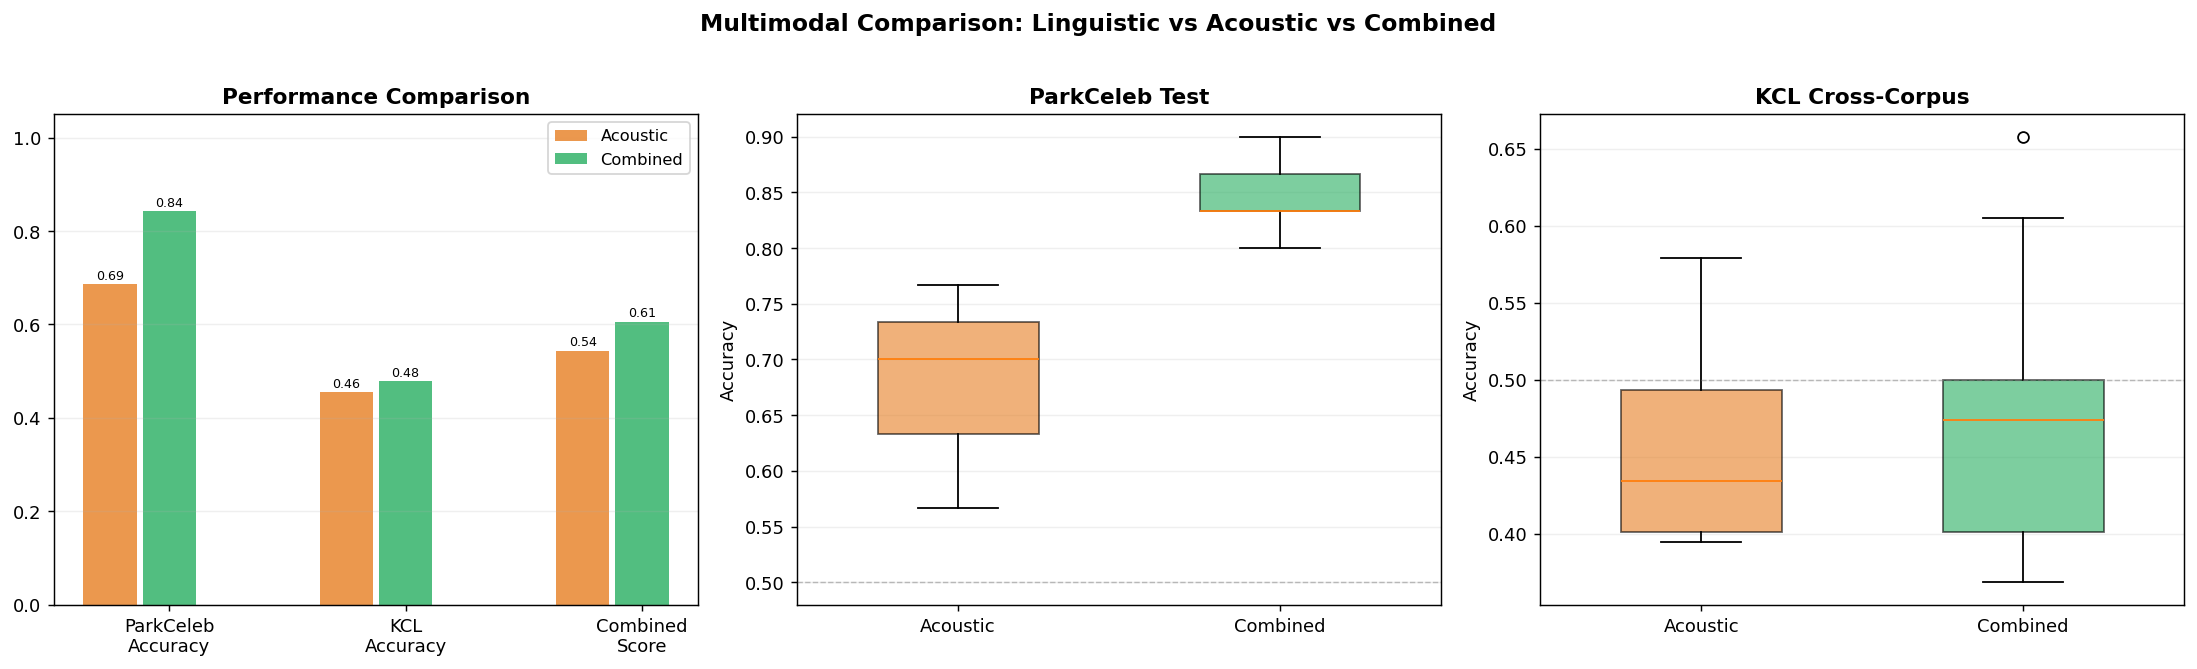

In [13]:
# ============================================================
# 3.4  Visualisation
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
#colors = {'Linguistic': '#3498DB', 'Acoustic': '#E67E22', 'Combined': '#27AE60'}
colors = {'Acoustic': '#E67E22', 'Combined': '#27AE60'}

# Bar chart
ax = axes[0]
metrics = ['pc_acc', 'kcl_acc', 'combined']
m_labels = ['ParkCeleb\nAccuracy', 'KCL\nAccuracy', 'Combined\nScore']
x = np.arange(len(metrics))
w = 0.25
for i, (label, color) in enumerate(colors.items()):
    vals = [summary.loc[label, m] for m in metrics]
    bars = ax.bar(x + i*w - w, vals, w*0.9, label=label, color=color, alpha=0.8)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{bar.get_height():.2f}', ha='center', fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(m_labels)
ax.set_ylim(0, 1.05); ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.2)
ax.set_title('Performance Comparison')

# Box plots PC
ax = axes[1]
data = [res_df[res_df['label']==l]['pc_acc'].values for l in colors.keys()]
bp = ax.boxplot(data, labels=list(colors.keys()), patch_artist=True, widths=0.5)
for patch, color in zip(bp['boxes'], colors.values()):
    patch.set_facecolor(color); patch.set_alpha(0.6)
ax.axhline(0.5, color='gray', ls='--', lw=0.8, alpha=0.5)
ax.set_ylabel('Accuracy'); ax.set_title('ParkCeleb Test'); ax.grid(axis='y', alpha=0.2)

# Box plots KCL
ax = axes[2]
if 'kcl_acc' in res_df.columns:
    data = [res_df[res_df['label']==l]['kcl_acc'].values for l in colors.keys()]
    bp = ax.boxplot(data, labels=list(colors.keys()), patch_artist=True, widths=0.5)
    for patch, color in zip(bp['boxes'], colors.values()):
        patch.set_facecolor(color); patch.set_alpha(0.6)
    ax.axhline(0.5, color='gray', ls='--', lw=0.8, alpha=0.5)
ax.set_ylabel('Accuracy'); ax.set_title('KCL Cross-Corpus'); ax.grid(axis='y', alpha=0.2)

plt.suptitle('Multimodal Comparison: Linguistic vs Acoustic vs Combined',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('multimodal_comparison.png', dpi=150, bbox_inches='tight'); plt.show()

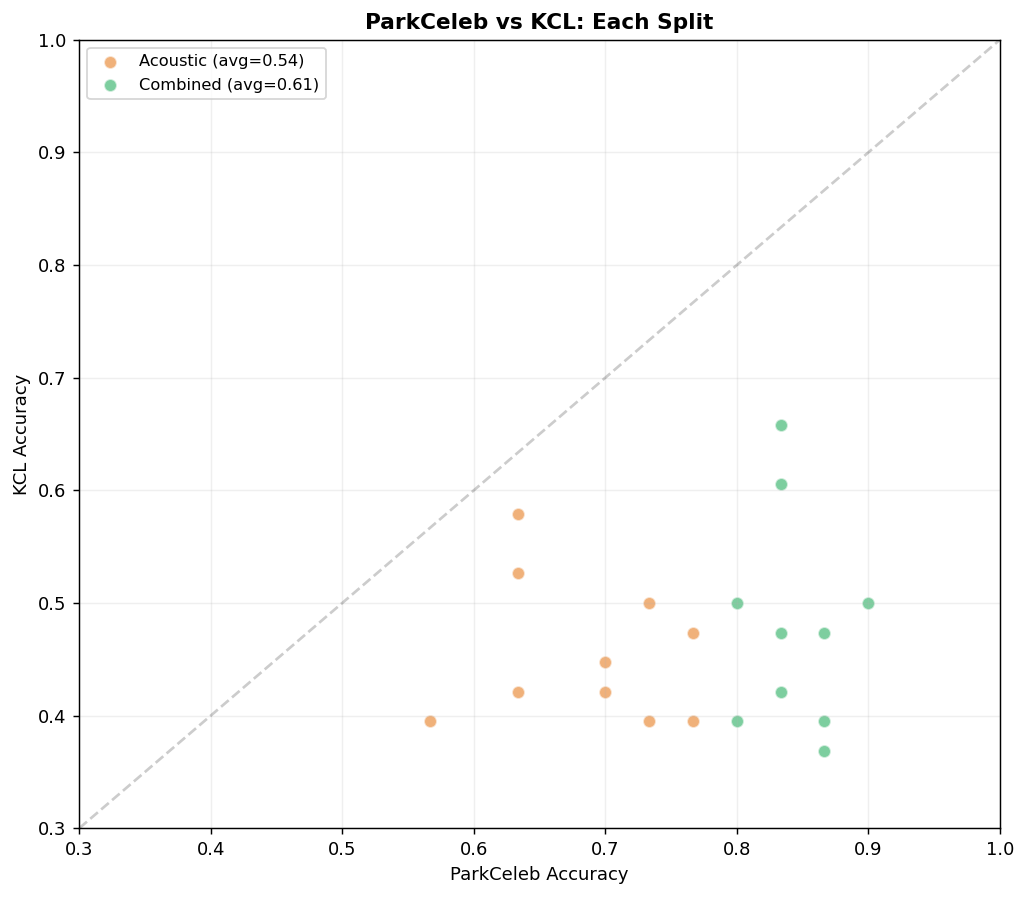

In [14]:
# ============================================================
# 3.5  Scatter: PC vs KCL for each experiment
# ============================================================
if 'kcl_acc' in res_df.columns:
    fig, ax = plt.subplots(figsize=(8, 7))
    for label, color in colors.items():
        sub = res_df[res_df['label'] == label]
        ax.scatter(sub['pc_acc'], sub['kcl_acc'], c=color, s=50, alpha=0.6,
                  label=f"{label} (avg={sub['combined'].mean():.2f})", edgecolors='white')
    ax.plot([0.3,1],[0.3,1], 'k--', alpha=0.2)
    ax.set_xlabel('ParkCeleb Accuracy'); ax.set_ylabel('KCL Accuracy')
    ax.set_title('ParkCeleb vs KCL: Each Split')
    ax.legend(fontsize=9); ax.grid(alpha=0.2)
    ax.set_xlim(0.3,1); ax.set_ylim(0.3,1)
    plt.tight_layout(); plt.savefig('multimodal_scatter.png', dpi=150, bbox_inches='tight'); plt.show()

---
## 4 — Train and save the best model

In [18]:
# ============================================================
# 4.1  Pick the best modality and train final model
# ============================================================
best_modality = summary['combined'].idxmax()
modality_feats = {'Linguistic': ling_features, 'Acoustic': ac_feat_cols, 'Combined': combined_feats}
best_feats = modality_feats[best_modality]

print(f'Best modality: {best_modality} ({len(best_feats)} features)')
print(f'Features: {best_feats}\n')

# Train on ALL ParkCeleb subjects
final_scaler = StandardScaler()
X_all = final_scaler.fit_transform(pc_combined[best_feats].values)
y_all = pc_combined['label'].values

final_rf = RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=3,
                                   max_features='sqrt', class_weight='balanced',
                                   random_state=42, n_jobs=-1)

final_rf.fit(X_all, y_all)

print(final_rf.get_params)
target_params = ['n_estimators', 'max_depth', 'min_samples_leaf', 'max_features']
parameters_dict = {k: final_rf.get_params()[k] for k in target_params if k in final_rf.get_params()}

print(f"Parameters: {parameters_dict}")

# Save
joblib.dump({
    'model': final_rf,
    'scaler': final_scaler,
    'features': best_feats,
    'ling_features': ling_features,
    'acoustic_features': ac_feat_cols,
    'modality': best_modality,
}, 'rf_multimodal.joblib')
print('Saved: rf_multimodal.joblib')

Best modality: Combined (27 features)
Features: ['N2SLOb', 'lwVAR', 'TOPhea', 'PRNposs1p', 'NSAOb', 'TOPent', 'T50KCOCAw', 'PRNposs2', 'TOPpol', 'NSLOb', 'DETposs1s', 'QUANTon', 'EMOmel', 'TOPspo', 'N2SNOb', 'EMOann', 'N2SFWOb', 'QUANTmn', 'CONJscond', 'DPCOCAanorm', 'PRNref2p', 'TOPtec', 'vVAR2', 'EMOfea', 'ac_f0_std', 'ac_f0_range', 'ac_speech_frac']

<bound method BaseEstimator.get_params of RandomForestClassifier(class_weight='balanced', max_depth=5, min_samples_leaf=3,
                       n_estimators=200, n_jobs=-1, random_state=42)>
Parameters: {'n_estimators': 200, 'max_depth': 5, 'min_samples_leaf': 3, 'max_features': 'sqrt'}
Saved: rf_multimodal.joblib


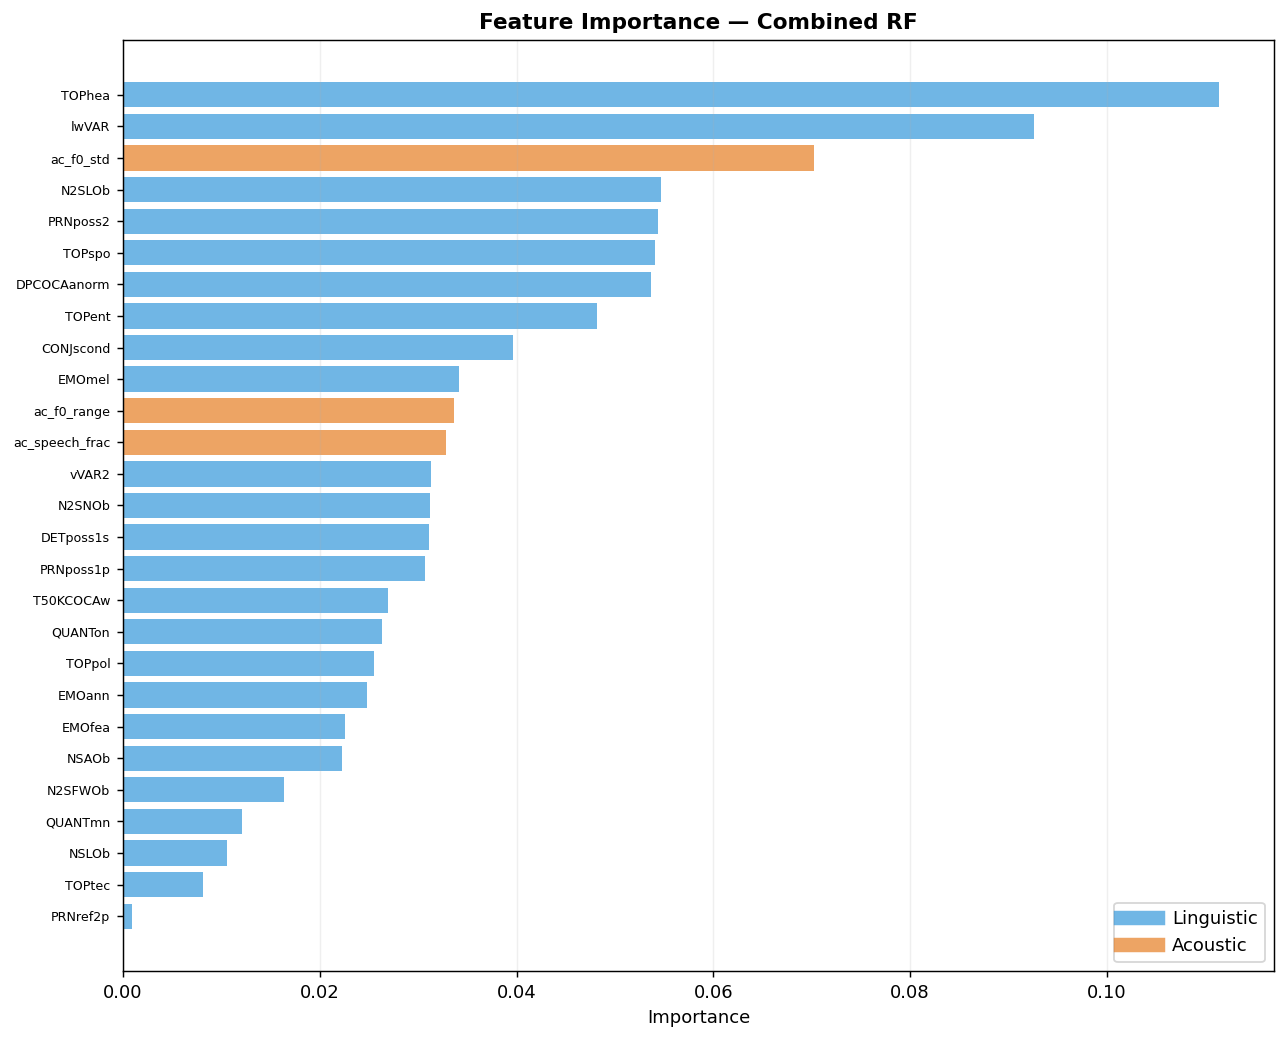


Rank  Feature                              Importance Type        
─────────────────────────────────────────────────────────────────
1     TOPhea                                   0.1114 Linguistic  
2     lwVAR                                    0.0926 Linguistic  
3     ac_f0_std                                0.0702 Acoustic    
4     N2SLOb                                   0.0547 Linguistic  
5     PRNposs2                                 0.0544 Linguistic  
6     TOPspo                                   0.0540 Linguistic  
7     DPCOCAanorm                              0.0536 Linguistic  
8     TOPent                                   0.0482 Linguistic  
9     CONJscond                                0.0397 Linguistic  
10    EMOmel                                   0.0341 Linguistic  
11    ac_f0_range                              0.0336 Acoustic    
12    ac_speech_frac                           0.0328 Acoustic    
13    vVAR2                                    0.0313 Linguist

In [16]:
# ============================================================
# 4.2  Feature importance of the final model
# ============================================================
imp = final_rf.feature_importances_
idx = np.argsort(imp)[::-1]

fig, ax = plt.subplots(figsize=(10, max(5, len(best_feats)*0.3)))

bar_colors = ['#3498DB' if best_feats[i] in ling_features else '#E67E22' for i in idx]
ax.barh(range(len(idx)), imp[idx], color=bar_colors, alpha=0.7)
ax.set_yticks(range(len(idx)))
ax.set_yticklabels([best_feats[i] for i in idx], fontsize=7)
ax.set_xlabel('Importance')
ax.set_title(f'Feature Importance — {best_modality} RF')
ax.invert_yaxis(); ax.grid(axis='x', alpha=0.2)

ling_p = plt.Line2D([0],[0], color='#3498DB', lw=8, alpha=0.7, label='Linguistic')
ac_p = plt.Line2D([0],[0], color='#E67E22', lw=8, alpha=0.7, label='Acoustic')
ax.legend(handles=[ling_p, ac_p], loc='lower right')

plt.tight_layout(); plt.savefig('multimodal_importance.png', dpi=150, bbox_inches='tight'); plt.show()

# Print ranked
print(f'\n{"Rank":<5s} {"Feature":<35s} {"Importance":>11s} {"Type":<12s}')
print('─' * 65)
for rank, i in enumerate(idx):
    feat_type = 'Linguistic' if best_feats[i] in ling_features else 'Acoustic'
    print(f'{rank+1:<5d} {best_feats[i]:<35s} {imp[i]:>11.4f} {feat_type:<12s}')

FINAL KCL CROSS-CORPUS (Combined RF)
  Accuracy: 0.447  AUC: 0.543
  Misclassified: 21/38


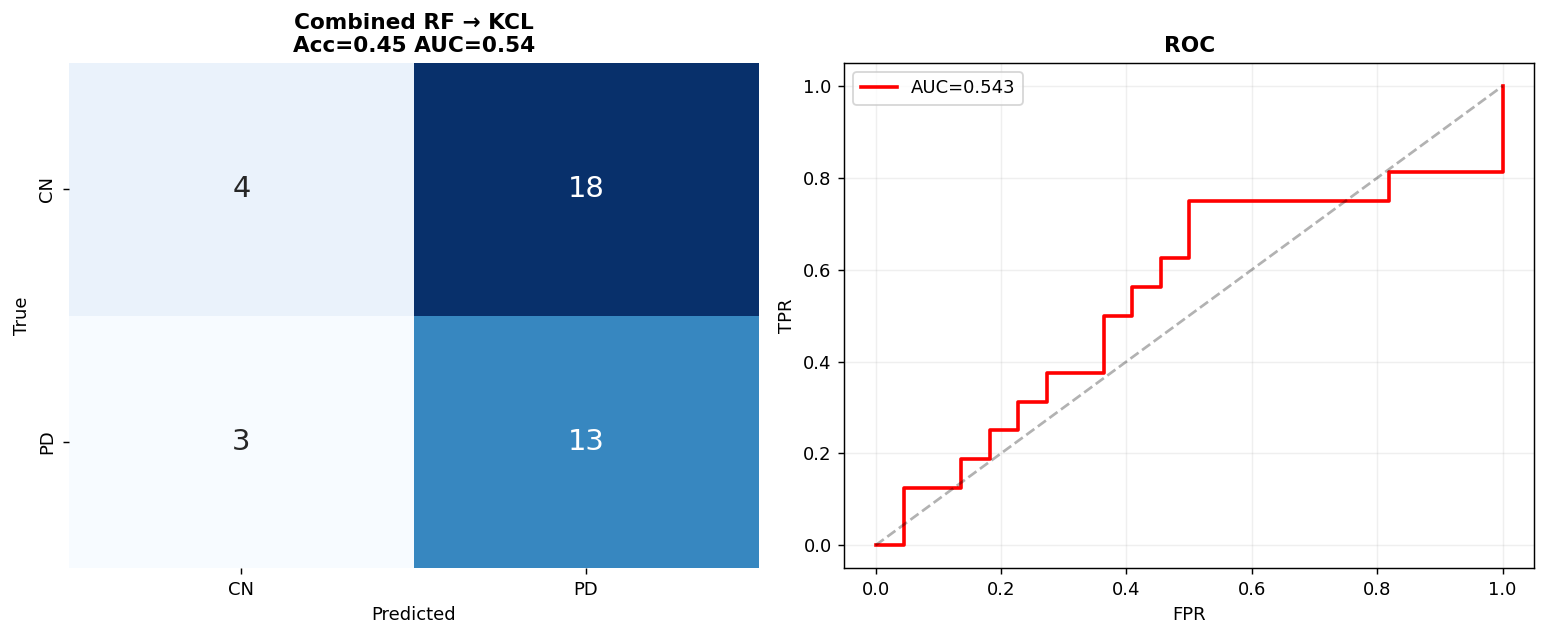

In [17]:
# ============================================================
# 4.3  Final KCL evaluation
# ============================================================
if kcl_combined is not None:
    for col in best_feats:
        if col not in kcl_combined.columns:
            kcl_combined[col] = 0.0
    
    X_kcl = final_scaler.transform(kcl_combined[best_feats].fillna(0).values)
    y_kcl = kcl_combined['label'].values
    kcl_pred = final_rf.predict(X_kcl)
    kcl_prob = final_rf.predict_proba(X_kcl)[:, 1]
    
    acc = accuracy_score(y_kcl, kcl_pred)
    auc_val = roc_auc_score(y_kcl, kcl_prob) if len(np.unique(y_kcl)) > 1 else 0.5
    
    print(f'FINAL KCL CROSS-CORPUS ({best_modality} RF)')
    print(f'  Accuracy: {acc:.3f}  AUC: {auc_val:.3f}')
    print(f'  Misclassified: {sum(y_kcl != kcl_pred)}/{len(y_kcl)}')
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    cm = confusion_matrix(y_kcl, kcl_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['CN','PD'], yticklabels=['CN','PD'], cbar=False, annot_kws={'size':16})
    axes[0].set_title(f'{best_modality} RF → KCL\nAcc={acc:.2f} AUC={auc_val:.2f}')
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
    
    fpr, tpr, _ = roc_curve(y_kcl, kcl_prob)
    axes[1].plot(fpr, tpr, 'r-', lw=2, label=f'AUC={auc_val:.3f}')
    axes[1].plot([0,1],[0,1],'k--',alpha=0.3); axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
    axes[1].set_title('ROC'); axes[1].legend(); axes[1].grid(alpha=0.2)
    plt.tight_layout(); plt.savefig('multimodal_kcl_eval.png', dpi=150, bbox_inches='tight'); plt.show()